# Exploratory Data Analysis (EDA) of Processed Data

## Goal
Analyze the quality and characteristics of the balanced dataset (`data/processed/master_metadata.csv`).

### Key Checks
1.  **Class Balance**: Verify ~200 samples per class.
2.  **Duration Analysis**: Check clip lengths and identify potential issues (e.g., extremely short clips).
3.  **Sample Rate Consistency**: Ensure all files have a consistent sample rate.
4.  **Spectral Analysis**: Visualize Mel-Spectrograms to confirm class distinctiveness.
5.  **Energy Analysis**: Compare RMS Energy across classes.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np
import os
from tqdm import tqdm

# Settings
META_PATH = '../data/processed/master_metadata.csv'
AUDIO_DIR = '../data/processed/audio/'

# Plot style
plt.style.use('ggplot')

## 1. Load Data & Class Balance Check

Total Samples: 920

Counts per Class:
class
Dog Bark       200
Car Horn       200
Siren          200
Door Knock     160
Crying Baby    160
Name: count, dtype: int64


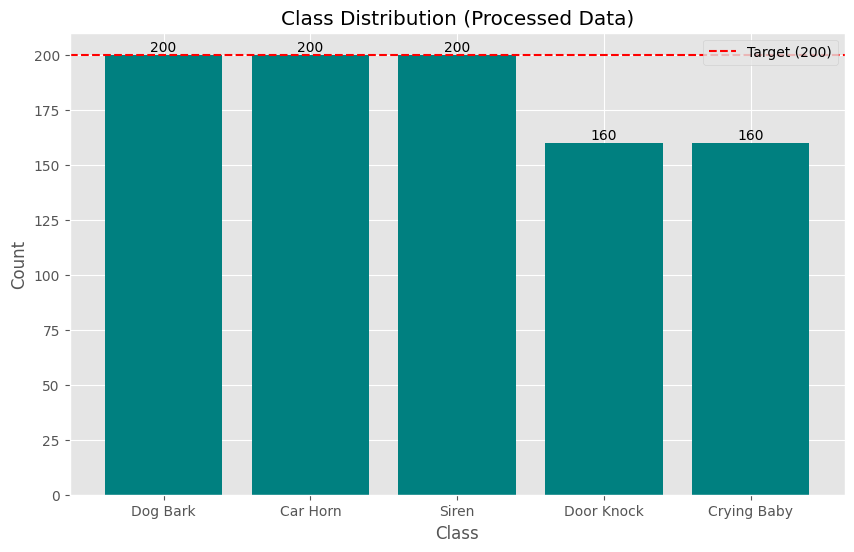

In [9]:
df = pd.read_csv(META_PATH)
print(f"Total Samples: {len(df)}")

# Check Balance
class_counts = df['class'].value_counts()
print("\nCounts per Class:")
print(class_counts)

# Visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(class_counts.index, class_counts.values, color='teal')
plt.title('Class Distribution (Processed Data)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.axhline(y=200, color='r', linestyle='--', label='Target (200)')
plt.legend()

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.show()

## 2. Technical Analysis (Duration & Sample Rate)

In [10]:
durations = []
sample_rates = []
energies = []

print("Analyzing Audio Properties...")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    file_path = row['filepath']
    # Adjust path if running from notebooks dir
    if not os.path.exists(file_path):
         # Try relative to notebook if path in CSV is relative to project root
         # Assuming CSV has '../data/processed/audio/filename'
         pass
    
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
        rms = np.sqrt(np.mean(y**2))
        
        durations.append(duration)
        sample_rates.append(sr)
        energies.append(rms)
        
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        durations.append(None)
        sample_rates.append(None)
        energies.append(None)

df['duration'] = durations
df['sample_rate'] = sample_rates
df['rms_energy'] = energies

Analyzing Audio Properties...


100%|██████████| 920/920 [00:01<00:00, 676.10it/s]


### Duration Analysis

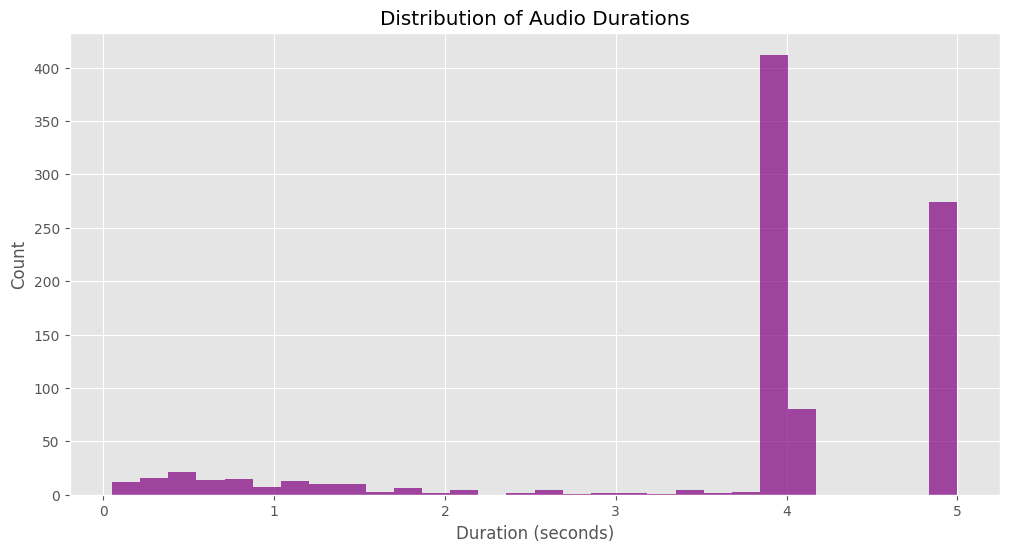

Duration Statistics:
count    920.000000
mean       3.837040
std        1.331416
min        0.050000
25%        4.000000
50%        4.000000
75%        5.000000
max        5.000000
Name: duration, dtype: float64


In [11]:
plt.figure(figsize=(12, 6))
plt.hist(df['duration'].dropna(), bins=30, color='purple', alpha=0.7)
plt.title('Distribution of Audio Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.show()

print("Duration Statistics:")
print(df['duration'].describe())

### Sample Rate Consistency

In [12]:
sr_counts = df['sample_rate'].value_counts()
print("Sample Rates Found:")
print(sr_counts)

if len(sr_counts) > 1:
    print("\nWARNING: Multiple sample rates detected! Feature extraction pipeline MUST handle resampling.")
else:
    print("\nSUCCESS: All files have consistent sample rate.")

Sample Rates Found:
sample_rate
44100    703
48000    173
96000     23
16000     10
11025      5
22050      4
24000      1
32000      1
Name: count, dtype: int64



## 3. Spectral Analysis (Mel-Spectrograms)
Comparing visual patterns of different classes.

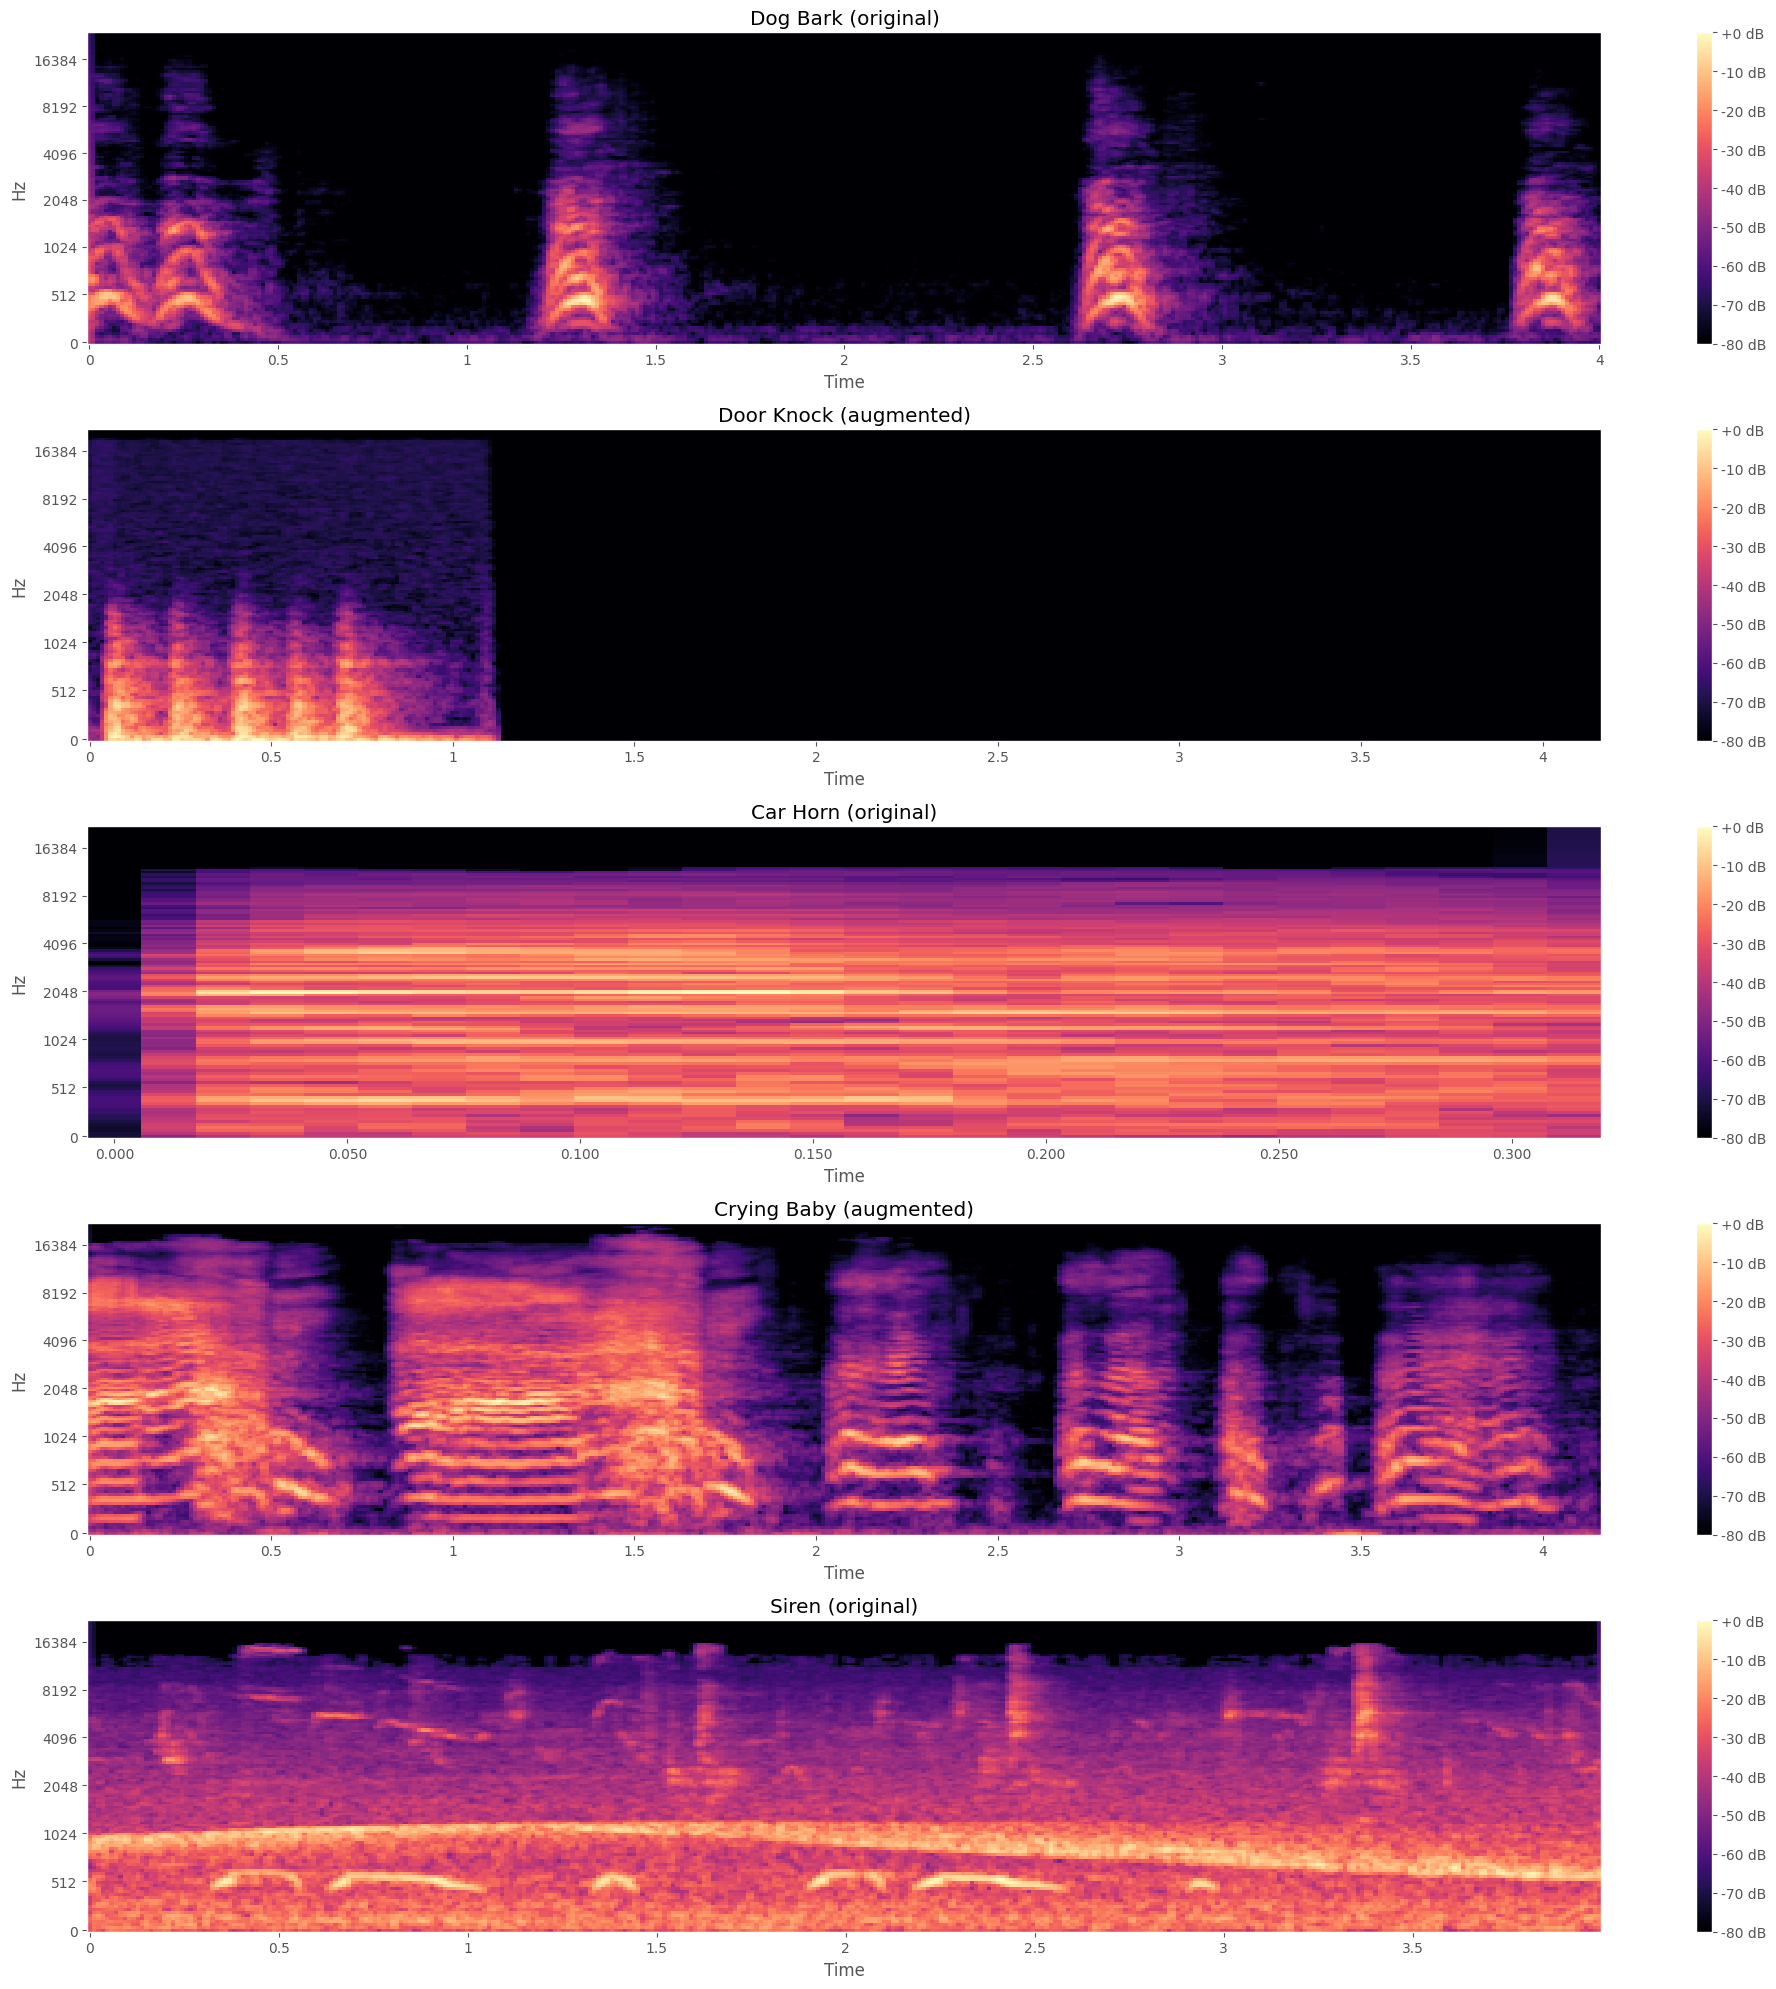

In [13]:
def plot_class_spectrograms(df, n_mels=128):
    classes = df['class'].unique()
    
    plt.figure(figsize=(20, 4 * len(classes)))
    
    for i, label in enumerate(classes):
        # Get a random sample
        sample_row = df[df['class'] == label].sample(1, random_state=42).iloc[0]
        file_path = sample_row['filepath']
        
        y, sr = librosa.load(file_path, sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        S_dB = librosa.power_to_db(S, ref=np.max)
        
        plt.subplot(len(classes), 1, i + 1)
        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f'{label} ({sample_row["type"]})')
        plt.tight_layout()

plot_class_spectrograms(df)

## 4. Energy Analysis (RMS)
Checking if loudness is a potential bias.

<Figure size 1200x600 with 0 Axes>

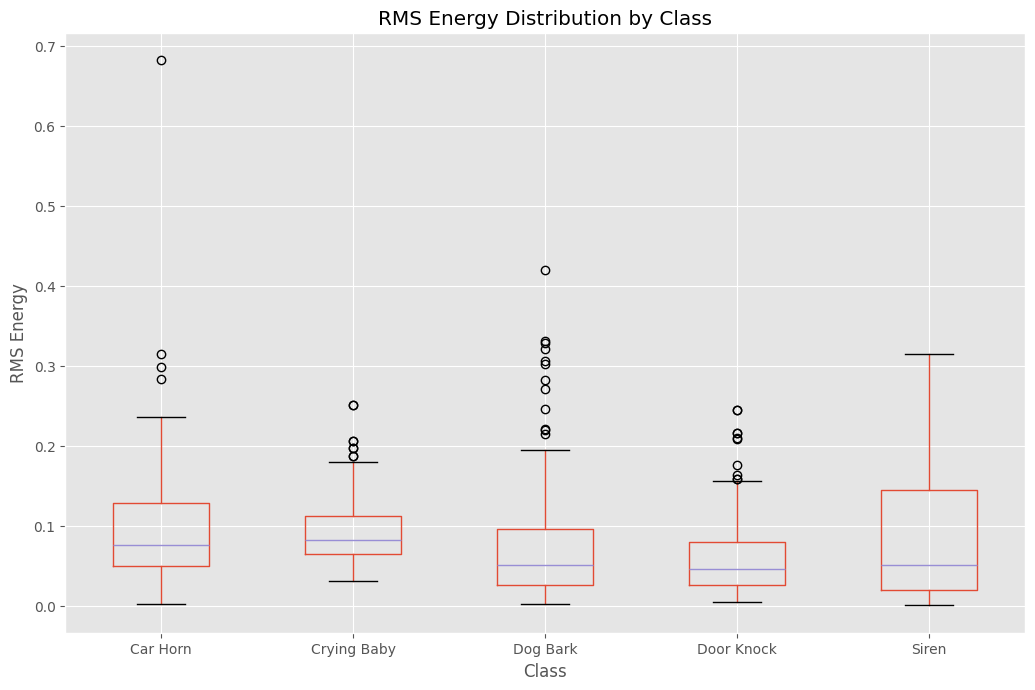

In [14]:
plt.figure(figsize=(12, 6))
df.boxplot(column='rms_energy', by='class', figsize=(12, 8))
plt.title('RMS Energy Distribution by Class')
plt.suptitle('')
plt.xlabel('Class')
plt.ylabel('RMS Energy')
plt.show()